In [1]:
from google.colab import userdata
import pandas as pd
import numpy as np
import os

# Настройка подключения к clearml-серверу
Предварительно следует настроить ключи в разделе секретов в google colab

In [2]:
%env CLEARML_WEB_HOST=https://app.clear.ml
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml

env: CLEARML_WEB_HOST=https://app.clear.ml
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml


In [3]:
os.environ['CLEARML_API_ACCESS_KEY'] = userdata.get('CLEARML_API_ACCESS_KEY')
os.environ['CLEARML_API_SECRET_KEY'] = userdata.get('CLEARML_API_SECRET_KEY')

In [4]:
%env CLEARML_SDK_DATASETS_DEFAULT_BASE_URI=s3://kaftaranov-mlops-kursovaya/clearml-datasets/
%env CLEARML_SDK_STORAGE_DEFAULT_BASE_URI=s3://kaftaranov-mlops-kursovaya/clearml-artifacts/

env: CLEARML_SDK_DATASETS_DEFAULT_BASE_URI=s3://kaftaranov-mlops-kursovaya/clearml-datasets/
env: CLEARML_SDK_STORAGE_DEFAULT_BASE_URI=s3://kaftaranov-mlops-kursovaya/clearml-artifacts/


In [5]:
# Проверка альтернативного указания URI
%env CLEARML__SDK__STORAGE__DEFAULT_BASE_URI=s3://kaftaranov-mlops-kursovaya/clearml-datasets/
%env CLEARML__SDK__DATASETS__DEFAULT_BASE_URI=s3://kaftaranov-mlops-kursovaya/clearml-artifacts/

env: CLEARML__SDK__STORAGE__DEFAULT_BASE_URI=s3://kaftaranov-mlops-kursovaya/clearml-datasets/
env: CLEARML__SDK__DATASETS__DEFAULT_BASE_URI=s3://kaftaranov-mlops-kursovaya/clearml-artifacts/


In [6]:
!pip install clearml[s3] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.1 MB/s eta 0:00:00


In [7]:
from clearml import Task, Logger, Dataset, StorageManager
from pathlib import Path
from datetime import datetime

In [ ]:
try:
    task = Task.init(
        project_name = "airline review sentiment analysis",
        task_name="ClearML S3 connection test",
        task_type=Task.TaskTypes.testing
    )
    Logger.current_logger().report_text(f"Test task initialized successfully {datetime.now()}")
    print("Успешно подключено к ClearML")

    with open("test_artifact.txt", "w") as f:
        f.write("Hello, S3 storage!")

    task.upload_artifact(
        name="s3_test",
        artifact_object="test_artifact.txt"
    )
    print('Артефакт загружен в S3')

except Exception as e:
    print(e)

finally:
    task.close()
    print("Успешное завершение задачи")

ClearML Task: created new task id=5d1ccaaa54884dc6826f81138725a609
ClearML results page: https://app.clear.ml/projects/d43ba604c27c4954956d1210c68a2a1a/experiments/5d1ccaaa54884dc6826f81138725a609/output/log
Test task initialized successfully 2025-11-24 17:45:52.124211
Успешно подключено к ClearML
Артефакт загружен в S3
ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
Успешное завершение задачи


# Подключение к S3-хранилищу, сохранения датасета

# Препроцессинг данных
Прототип перед переводом в код для репозитория

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("chaudharyanshul/airline-reviews")

100%|██████████| 1.30M/1.30M [00:00<00:00, 48.4MB/s]

Extracting files...


In [ ]:
os.listdir(path)

['BA_AirlineReviews.csv']

In [ ]:
csv_path = os.path.join(path, "BA_AirlineReviews.csv")
df = pd.read_csv(csv_path)
df.head(1)

,Unnamed: 0,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,SeatComfort,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity
0,0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,"4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise, 4h before departure? Anyhow - we took the one hour delay so what - but then we have been forced to check in our Hand luggage. I travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. Overall 2h later at home than planed, with really no reason, just due to incompetent people. Service le...",Couple Leisure,Economy Class,London to Stuttgart,November 2023,1.0,1.0,1.0,1.0,no,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['Unnamed: 0', 'OverallRating', 'ReviewHeader', 'Name', 'Datetime',
       'VerifiedReview', 'ReviewBody', 'TypeOfTraveller', 'SeatType', 'Route',
       'DateFlown', 'SeatComfort', 'CabinStaffService', 'GroundService',
       'ValueForMoney', 'Recommended', 'Aircraft', 'Food&Beverages',
       'InflightEntertainment', 'Wifi&Connectivity'],
      dtype='object')

In [ ]:
df = df[['ReviewBody', 'OverallRating']]
df.to_csv('raw_review_rating.csv')

In [ ]:
ds = Dataset.create(
    dataset_name='airline_sentiment_body',
    dataset_project='airline-sentiment-analysis',
    description='Только ReviewBody и OverallRating'
)

ClearML results page: https://app.clear.ml/projects/9d534e3200204e69af30c528e4e3ebff/experiments/de66d35457e541c4872c14b8781629d1/output/log
ClearML dataset page: https://app.clear.ml/datasets/simple/9d534e3200204e69af30c528e4e3ebff/experiments/de66d35457e541c4872c14b8781629d1


In [ ]:
ds.add_files(path='raw_review_rating.csv')

1

In [ ]:
ds.upload()

File compression and upload completed: total size 0 B, 0 chunk(s) stored (average size 0 B)


True

In [ ]:
ds.finalize()
ds.id

'de66d35457e541c4872c14b8781629d1'

# Предобработка

## Label-кодирование

In [ ]:
ds_label_encoded = Dataset.get(
    dataset_name='airline_sentiment_body',
    dataset_project='airline-sentiment-analysis'
)

In [ ]:
path = ds_label_encoded.get_mutable_local_copy('/content/drive/MyDrive/Colab Notebooks/Airline Sentiment Analysis/Untitled Folder')

In [ ]:
df_label_encoded = pd.read_csv(os.path.join(path, os.listdir(path)[0]))
df_label_encoded.head(1)

,Unnamed: 0,ReviewBody,OverallRating
0,0,"4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise, 4h before departure? Anyhow - we took the one hour delay so what - but then we have been forced to check in our Hand luggage. I travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. Overall 2h later at home than planed, with really no reason, just due to incompetent people. Service le...",1.0


In [ ]:
df_label_encoded.drop('Unnamed: 0', inplace=True, axis=1)

In [ ]:
df_label_encoded['OverallRating'].unique()

array([ 1.,  3.,  8.,  7.,  2.,  6.,  4.,  5., 10.,  9., nan])

In [ ]:
df_label_encoded.rename(
    columns={
        'OverallRating' : 'overall_rating',
        'ReviewBody' : 'review_body'
    },
    inplace=True)

In [ ]:
df_label_encoded['label'] = df_label_encoded['overall_rating'].apply(
    lambda x : 'negative' if x <= 3 else 'neutral' if x <= 7 else 'positive'
    )

df_label_encoded['label_value'] = df_label_encoded['overall_rating'].apply(
    lambda x : 0 if x <= 3 else 1 if x <= 7 else 2
    )

In [ ]:
df_label_encoded.head()

,review_body,overall_rating,label,label_value
0,"4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise, 4h before departure? Anyhow - we took the one hour delay so what - but then we have been forced to check in our Hand luggage. I travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. Overall 2h later at home than planed, with really no reason, just due to incompetent people. Service le...",1.0,negative,0
1,"I recently had a delay on British Airways from BRU to LHR that was due to staff shortages. They announced that there was a 2 hour holding delay but they would board us immediately in hopes of clearing the gate and leaving early. We had to wait the full 2 hours inside the airplane. The plane was old, dirty, had no power at the seats. The staff provided a small bag of pretzels and 250ml of water to the passengers for 2 hour delay and 2 hour flight. There were no options to purchase food or drink. There were no entertainment options available. I am a OneWorld emerald elite member but they do ...",3.0,negative,0
2,"Boarded on time, but it took ages to get to the runway due to congestion. Flight was smooth and quick. Snack and drinks were good for a short flight. Landed only about ten minutes late. One bag of three left in London, forms quickly filled in, and the bag was delivered the next morning.",8.0,positive,2
3,"5 days before the flight, we were advised by BA that it had been cancelled and asked us to rebook. There were flights 1 hour before and 1 hour after our original flight but they made us take one 3 hours earlier. Our original ticket (and the return flight a week later) included a checked bag. When we arrive at Heathrow to check in we are told our ticket doesn't included a bag and we will have to pay 75 pounds each to take them. We explained that the original ticket had the bags and when they checked the system they confirmed that it did- but not this one! They would make no effort to sort i...",1.0,negative,0
4,"We traveled to Lisbon for our dream vacation, a cruise to Portugal and Spain. Our friends did not EVER get their luggage. It was a two week cruise. Two weeks without a change of clothes or her CPAP machine. Contacting customer service was a nightmare. We never talked to a real person. Very little effort was put into getting them their bags. In one port we were on the ship and the bags were at the airport. The airlines did not deliver the bags nor did they tell our friends that they needed to go get them. The airline couldn’t be bothered to take the bags from the airport to the ship. BA say...",1.0,negative,0


## Удаление пропусков

In [ ]:
len(df_label_encoded), len(df_label_encoded.dropna())

(3701, 3696)

In [ ]:
df_label_encoded.dropna(inplace=True)

In [ ]:
df_label_encoded.to_csv('labeled_airline_sentiment.csv')

In [ ]:
ds_label_encoded = Dataset.create(
    dataset_name='labeled_airline_sentiment',
    dataset_project="airline-sentiment-analysis",
    parent_datasets=[ds.id],
    description="""
    Проставлен label и label_value в зависимости от overall_rating:
        [1, 3]  -   negative -  0
        [4, 7]  -   neutral  -  1
        [8, 10] -   positive -  2
    Удалены все пропуски.
    """
)

ClearML results page: https://app.clear.ml/projects/6a83a0f888ff4f3d9bede17ed7414ab5/experiments/668b17e43b76450883c62aa378b9790d/output/log
ClearML dataset page: https://app.clear.ml/datasets/simple/6a83a0f888ff4f3d9bede17ed7414ab5/experiments/668b17e43b76450883c62aa378b9790d


In [ ]:
ds_label_encoded.list_files()

['raw_review_rating.csv']

In [ ]:
ds_label_encoded.remove_files('raw_review_rating.csv')

1

In [ ]:
ds_label_encoded.add_files('labeled_airline_sentiment.csv')

1

In [ ]:
ds_label_encoded.upload()
ds_label_encoded.finalize()

Uploading dataset changes (1 files compressed to 1.15 MiB) to https://files.clear.ml
File compression and upload completed: total size 1.15 MiB, 1 chunk(s) stored (average size 1.15 MiB)


True

In [ ]:
test_ds = Dataset.get(
    dataset_name='airline_sentiment_body',
    dataset_project='airline-sentiment-analysis'
)
path = test_ds.get_local_copy()
path

'/root/.clearml/cache/storage_manager/datasets/ds_de66d35457e541c4872c14b8781629d1'

In [ ]:
df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))
df.head(1)

,Unnamed: 0,ReviewBody,OverallRating
0,0,"4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise, 4h before departure? Anyhow - we took the one hour delay so what - but then we have been forced to check in our Hand luggage. I travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. Overall 2h later at home than planed, with really no reason, just due to incompetent people. Service le...",1.0


## Переименование столбцов
1. ReviewBody -> text
2. OverallRating -> label

In [ ]:
ds = Dataset.get(
    dataset_name='airline_sentiment_body',
    dataset_project='airline-sentiment-analysis',
    alias='latest'
)

path = ds.get_local_copy()

df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))
df.head(1)

,Unnamed: 0,ReviewBody,OverallRating
0,0,"4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise, 4h before departure? Anyhow - we took the one hour delay so what - but then we have been forced to check in our Hand luggage. I travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. Overall 2h later at home than planed, with really no reason, just due to incompetent people. Service le...",1.0


In [ ]:
df = df.rename(columns={
    'ReviewBody' : 'text',
    'OverallRating' : 'label'
})

df = df[['text', 'label']]

In [ ]:
df.columns

Index(['text', 'label'], dtype='object')

In [ ]:
df.to_csv('renamed_sentiment_body.csv', index=False)

In [ ]:
renamed_ds = Dataset.create(
    dataset_name='airline_sentiment_body',
    dataset_project="airline-sentiment-analysis",
    parent_datasets=[ds.id]
)

ClearML results page: https://app.clear.ml/projects/9d534e3200204e69af30c528e4e3ebff/experiments/200e61e04599466f9991bd016a604fe8/output/log
ClearML dataset page: https://app.clear.ml/datasets/simple/9d534e3200204e69af30c528e4e3ebff/experiments/200e61e04599466f9991bd016a604fe8


In [ ]:
renamed_ds.list_files()

['raw_review_rating.csv']

In [ ]:
renamed_ds.remove_files('raw_review_rating.csv')
renamed_ds.add_files('renamed_sentiment_body.csv')
renamed_ds.list_files()

['renamed_sentiment_body.csv']

In [ ]:
renamed_ds.upload()
renamed_ds.finalize()

Uploading dataset changes (1 files compressed to 1.13 MiB) to https://files.clear.ml
File compression and upload completed: total size 1.13 MiB, 1 chunk(s) stored (average size 1.13 MiB)


True

## Перевод label в int

In [ ]:
ds = Dataset.get(
    dataset_name='airline_sentiment_body',
    dataset_project='airline-sentiment-analysis',
    alias='latest'
)

path = ds.get_local_copy()

df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))
df.head(1)

,text,label
0,"4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise, 4h before departure? Anyhow - we took the one hour delay so what - but then we have been forced to check in our Hand luggage. I travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. Overall 2h later at home than planed, with really no reason, just due to incompetent people. Service le...",1.0


In [ ]:
df.label.isna().sum()

np.int64(5)

In [ ]:
df = df.dropna()
df.label = df.label.astype(int)

In [ ]:
df.to_csv(
    'int_label_sentiment_body.csv'
)

In [ ]:
int_label_ds = Dataset.create(
    dataset_name='airline_sentiment_body',
    dataset_project="airline-sentiment-analysis",
    parent_datasets=[ds.id]
)

ClearML results page: https://app.clear.ml/projects/9d534e3200204e69af30c528e4e3ebff/experiments/59971b6f9f8d4238a90abf02aeea2dce/output/log
ClearML dataset page: https://app.clear.ml/datasets/simple/9d534e3200204e69af30c528e4e3ebff/experiments/59971b6f9f8d4238a90abf02aeea2dce


In [ ]:
int_label_ds.list_files()

['renamed_sentiment_body.csv']

In [ ]:
int_label_ds.remove_files('renamed_sentiment_body.csv')
int_label_ds.add_files('int_label_sentiment_body.csv')
int_label_ds.list_files()

['int_label_sentiment_body.csv']

In [ ]:
int_label_ds.upload()
int_label_ds.finalize()

Uploading dataset changes (1 files compressed to 1.14 MiB) to https://files.clear.ml
File compression and upload completed: total size 1.14 MiB, 1 chunk(s) stored (average size 1.14 MiB)


True

In [ ]:
df.label.unique()

array([ 1,  3,  8,  7,  2,  6,  4,  5, 10,  9])

## Преобразоваение labeled-dataset'a

In [ ]:
ds_labeled = Dataset.get(
        dataset_name='labeled_airline_sentiment',
    dataset_project="airline-sentiment-analysis",
)
path = ds_labeled.get_local_copy()

df_labeled = pd.read_csv(os.path.join(path, os.listdir(path)[0]))
df_labeled.head(1)

,Unnamed: 0,review_body,overall_rating,label,label_value
0,0,"4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise, 4h before departure? Anyhow - we took the one hour delay so what - but then we have been forced to check in our Hand luggage. I travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. Overall 2h later at home than planed, with really no reason, just due to incompetent people. Service le...",1.0,negative,0


## Проверка баланса классов

In [ ]:
ds_labeled = Dataset.get(
        dataset_name='labeled_airline_sentiment',
    dataset_project="airline-sentiment-analysis",
)
path = ds_labeled.get_local_copy()

df_labeled = pd.read_csv(os.path.join(path, os.listdir(path)[0]))
df_labeled.head(1)

,Unnamed: 0,review_body,overall_rating,label,label_value
0,0,"4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise, 4h before departure? Anyhow - we took the one hour delay so what - but then we have been forced to check in our Hand luggage. I travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. Overall 2h later at home than planed, with really no reason, just due to incompetent people. Service le...",1.0,negative,0


In [ ]:
df_labeled.label.value_counts()

,count
label,
negative,1695
positive,1010
neutral,991


In [ ]:
ds_balanced = Dataset.create(
    dataset_name='balanced_sentiment_body',
    dataset_project="airline-sentiment-analysis",
    parent_datasets=[ds_labeled.id]
)

ClearML results page: https://app.clear.ml/projects/cc7a26b6b49141e890744e581f903eb6/experiments/5a4cbeb556064900afddbbd7d2296fa2/output/log
ClearML dataset page: https://app.clear.ml/datasets/simple/cc7a26b6b49141e890744e581f903eb6/experiments/5a4cbeb556064900afddbbd7d2296fa2


In [ ]:
ds_balanced.remove_files('labeled_airline_sentiment.csv')

1

In [ ]:
ds_balanced.list_files()

[]

In [ ]:
N = 991

df_balanced = (
    df_labeled
    .groupby("label", group_keys=False)
    .sample(n=N, random_state=42)
)

len(df_labeled), len(df_balanced)

(3696, 2973)

In [ ]:
df_balanced.to_csv('balanced_sentiment_body.csv', index=False)
ds_balanced.add_files('balanced_sentiment_body.csv')

ds_balanced.upload()
ds_balanced.finalize()

Uploading dataset changes (1 files compressed to 926.94 KiB) to https://files.clear.ml
File compression and upload completed: total size 926.94 KiB, 1 chunk(s) stored (average size 926.94 KiB)


True

# Перевод последней версии датасета в S3

In [ ]:
def main():
    # 1. Проверяем, что видит ClearML как default storage
    try:
        base_uri = StorageManager.get_default_base_url()
    except Exception as e:
        base_uri = f"<error: {e}>"

    print(f"[INFO] StorageManager default_base_uri: {base_uri}")
    print(f"[INFO] ENV CLEARML__SDK__STORAGE__DEFAULT_BASE_URI = {os.getenv('CLEARML__SDK__STORAGE__DEFAULT_BASE_URI')}")
    print(f"[INFO] ENV CLEARML__SDK__DATASETS__DEFAULT_BASE_URI = {os.getenv('CLEARML__SDK__DATASETS__DEFAULT_BASE_URI')}")

    # 2. Инициализация тестовой задачи
    task = Task.init(
        project_name="airline review sentiment analysis",
        task_name="ClearML S3 connection test",
        task_type=Task.TaskTypes.testing,
    )
    logger = Logger.current_logger()
    logger.report_text(f"Test task initialized successfully at {datetime.now()}")

    print(f"[INFO] Task id: {task.id}")

    # 3. Создаём локальный тестовый файл и загружаем как артефакт
    artifact_path = Path("s3_test_artifact.txt")
    artifact_path.write_text(f"Hello from ClearML S3 test at {datetime.now()}\n")

    print(f"[INFO] Local test file created: {artifact_path.resolve()}")

    task.upload_artifact(
        name="s3_test_file",
        artifact_object=str(artifact_path),
    )
    print("[INFO] Uploaded artifact 's3_test_file'")

    # 4. Загружаем Python-объект как артефакт (он тоже уйдёт в storage)
    task.upload_artifact(
        name="s3_test_dict",
        artifact_object={
            "timestamp": str(datetime.now()),
            "note": "This is a test dict for S3 storage",
        },
    )
    print("[INFO] Uploaded artifact 's3_test_dict'")

    # 5. (Опционально) создаём маленький Dataset и заливаем его в S3
    #    Если не нужно — этот блок можно закомментировать
    dataset_test_file = Path("s3_dataset_test.csv")
    dataset_test_file.write_text("text,label\nhello,0\nworld,1\n")

    ds = Dataset.create(
        dataset_name="clearml_s3_dataset_test",
        dataset_project="airline review sentiment analysis",
        dataset_version="test_s3_v1",
    )
    ds.add_files(str(dataset_test_file.resolve()))
    ds.upload()
    ds.finalize()

    print(f"[INFO] Dataset created. ID: {ds.id}")

    # 6. Закрываем задачу
    task.close()
    print("[INFO] Task closed successfully")

In [ ]:
main()

[INFO] StorageManager default_base_uri: <error: type object 'StorageManager' has no attribute 'get_default_base_url'>
[INFO] ENV CLEARML__SDK__STORAGE__DEFAULT_BASE_URI = s3://kaftaranov-mlops-kursovaya/clearml-datasets/
[INFO] ENV CLEARML__SDK__DATASETS__DEFAULT_BASE_URI = s3://kaftaranov-mlops-kursovaya/clearml-artifacts/
ClearML Task: created new task id=b9c1bd1005e8464fae78e4ef4729b32d
2025-11-24 17:44:07,825 - clearml.Task - INFO - Storing jupyter notebook directly as code
ClearML results page: https://app.clear.ml/projects/d43ba604c27c4954956d1210c68a2a1a/experiments/b9c1bd1005e8464fae78e4ef4729b32d/output/log
Test task initialized successfully at 2025-11-24 17:44:22.764139
[INFO] Task id: b9c1bd1005e8464fae78e4ef4729b32d
[INFO] Local test file created: /content/s3_test_artifact.txt
[INFO] Uploaded artifact 's3_test_file'
[INFO] Uploaded artifact 's3_test_dict'
2025-11-24 17:44:23,869 - clearml - WARNING - Setting non-semantic dataset version 'test_s3_v1'
ClearML Monitor: GPU mon

# EDA

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
# Получение датасета
ds_labeled = Dataset.get(
        dataset_name='labeled_airline_sentiment',
    dataset_project="airline-sentiment-analysis",
)
path = ds_labeled.get_local_copy()

df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))

In [11]:
df.head(1)

,Unnamed: 0,review_body,overall_rating,label,label_value
0,0,"4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise, 4h before departure? Anyhow - we took the one hour delay so what - but then we have been forced to check in our Hand luggage. I travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. Overall 2h later at home than planed, with really no reason, just due to incompetent people. Service le...",1.0,negative,0


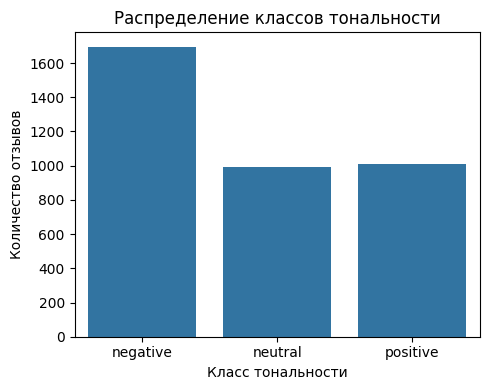

In [10]:
plt.figure(figsize=(5, 4))
sns.countplot(x="label", data=df, order=["negative", "neutral", "positive"])
plt.xlabel("Класс тональности")
plt.ylabel("Количество отзывов")
plt.title("Распределение классов тональности")
plt.tight_layout()
plt.show()

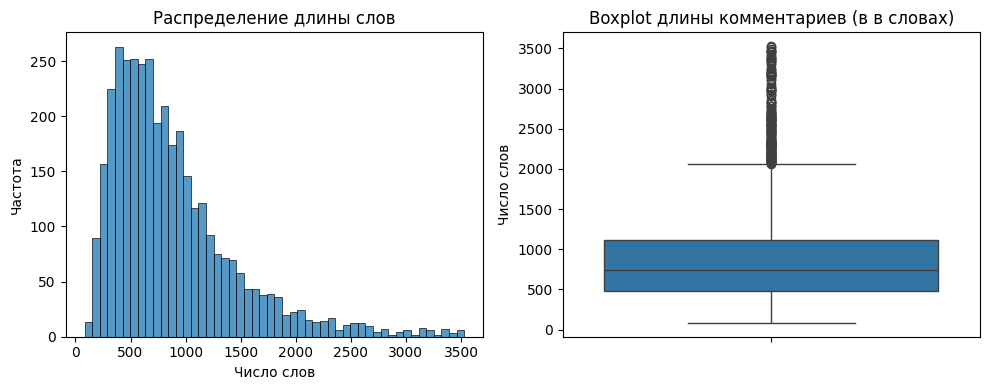

In [18]:
# Распеределение длины комментариев

df["len_chars"] = df["label"].astype(str).str.len()
df["len_tokens"] = df["review_body"].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df["len_tokens"], bins=50, ax=axes[0])
axes[0].set_title("Распределение длины слов")
axes[0].set_xlabel("Число слов")
axes[0].set_ylabel("Частота")
#axes[0].set_xlim(0, 60)

sns.boxplot(y=df["len_tokens"], ax=axes[1])
axes[1].set_title("Boxplot длины комментариев (в в словах)")
axes[1].set_ylabel("Число слов")

plt.tight_layout()
plt.show()